In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("Imports OK")

Imports OK


## Chargement des données

In [ ]:
X_scaled = pd.read_csv("../data/X_scaled.csv")
with open("../data/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
print(f"Données chargées")
print(f"X_scaled : {X_scaled.shape}")
print(f"Features : {list(X_scaled.columns)}")

Données chargées
X_scaled : (4443, 24)
y : (4443,)
Features : ['request_count', 'unique_ips', 'avg_response_time', 'median_response_time', 'p95_response_time', 'p99_response_time', 'max_response_time', 'std_response_time', 'error_rate_5xx', 'error_rate_4xx', 'success_rate', 'avg_bytes_sent', 'total_bytes_sent', 'bot_ratio', 'mobile_ratio', 'desktop_ratio', 'api_ratio', 'static_ratio', 'auth_ratio', 'get_ratio', 'post_ratio', 'hour', 'is_weekend', 'is_business_hours']

Distribution des labels :
is_anomaly
0    4309
1     134
Name: count, dtype: int64
Taux d'anomalies : 3.0%


## Préparation des Données

In [19]:
from sklearn.model_selection import train_test_split

# Split uniquement sur X, sans stratification par y
X_train, X_test = train_test_split(
    X_scaled, test_size=0.2, random_state=42
)

print(f"Split effectué")
print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

Split effectué
Train : (3554, 24)
Test  : (889, 24)


## Construction de l'AutoEncoder

In [8]:
input_dim = X_scaled.shape[1]

# Encoder 
inputs    = Input(shape=(input_dim,), name="input")
encoded   = Dense(16, activation="relu", name="encoder_1")(inputs)
bottleneck= Dense(8,  activation="relu", name="bottleneck")(encoded)

# Decoder 
decoded   = Dense(16, activation="relu", name="decoder_1")(bottleneck)
outputs   = Dense(input_dim, activation="linear", name="output")(decoded)

# Modèle complet 
autoencoder = Model(inputs, outputs, name="Autoencoder")
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Dense)               │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088 (4.25 KB)

 Trainable params: 1,088 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

## Entraînement

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = autoencoder.fit(
    X_train, X_train,        # pas de filtrage par y
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f"Entraînement terminé")
print(f"Epochs : {len(history.history['loss'])}")

Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.9940 - val_loss: 1.1115
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8942 - val_loss: 0.9575
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7493 - val_loss: 0.7832
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6518 - val_loss: 0.6870
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5686 - val_loss: 0.5906
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5049 - val_loss: 0.5456
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4671 - val_loss: 0.5137
Epoch 8/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4391 - val_loss: 0.4863
Epoch 9/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4107 - val_loss: 0.4651
Epoch 10/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3838 - val_loss: 0.4417
Epoch 11/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3552 - val_loss: 0.4262
Epoch 12/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3

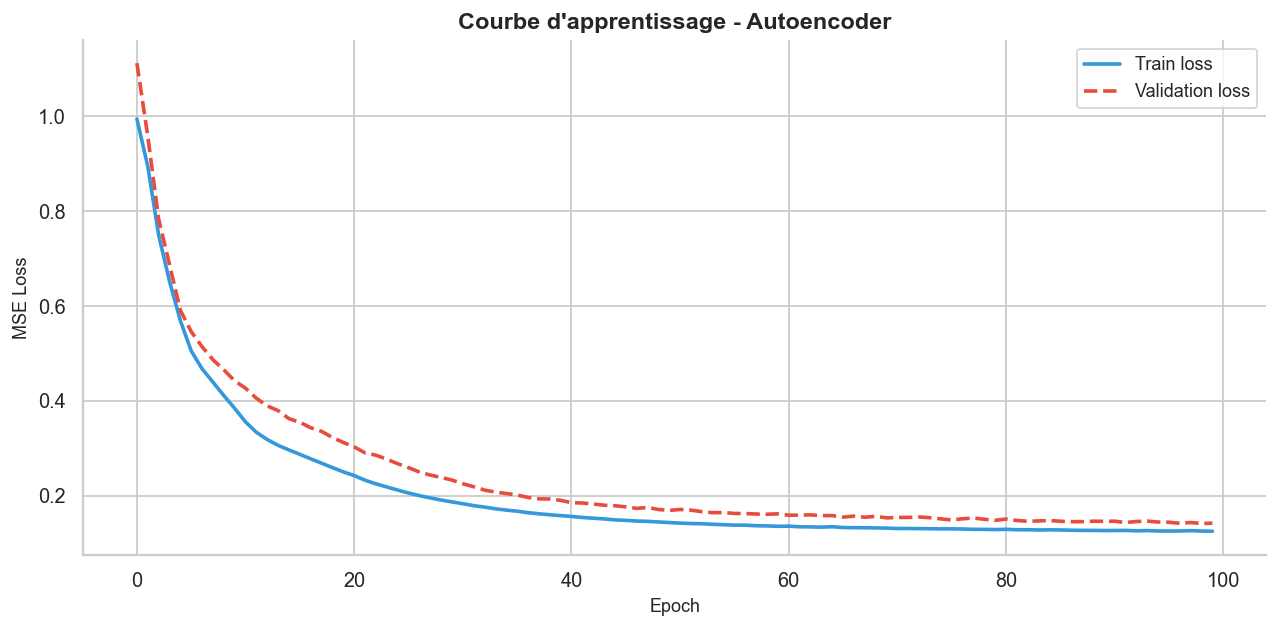

Figure sauvegardée : training_loss.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history["loss"], label="Train loss",      color="#3498db", linewidth=2)
ax.plot(history.history["val_loss"], label="Validation loss", color="#e74c3c", linewidth=2, linestyle="--")
ax.set_title("Courbe d'apprentissage - Autoencoder", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=10)
ax.set_ylabel("MSE Loss", fontsize=10)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("training_loss.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : training_loss.png")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Seuil (P95) : 0.347912
Anomalies détectées : 52 / 889


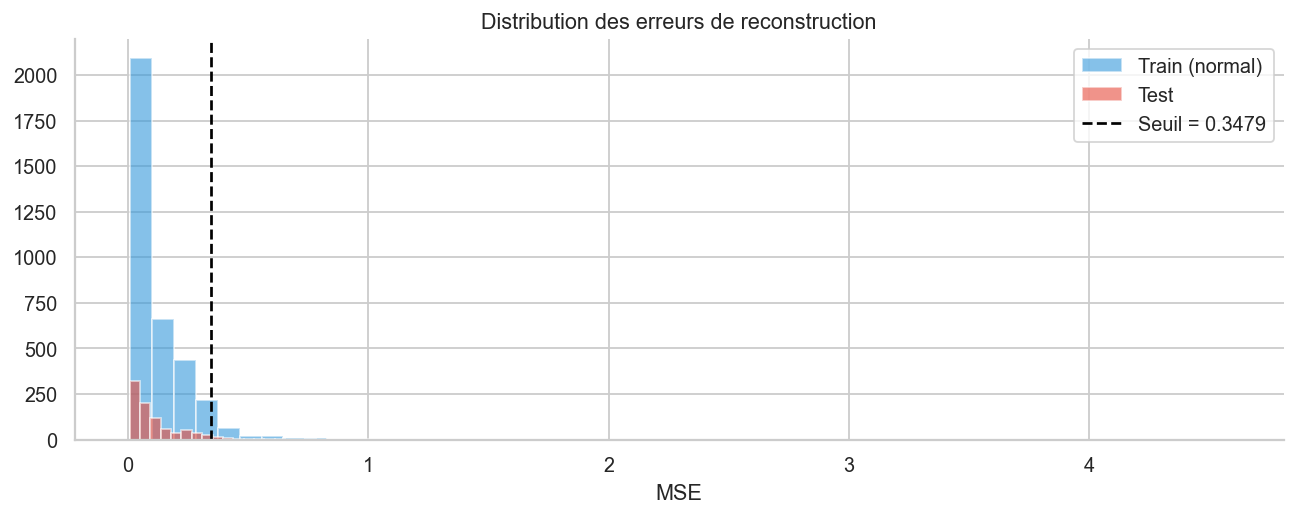

Modèle et seuil sauvegardés


In [21]:
# 1. Erreurs de reconstruction sur le test set
X_test_pred = autoencoder.predict(X_test)
reconstruction_errors = np.mean(np.square(X_test.values - X_test_pred), axis=1)

# 2. Seuil : moyenne + 3 écarts-types sur le train set
X_train_pred = autoencoder.predict(X_train)
train_errors = np.mean(np.square(X_train.values - X_train_pred), axis=1)
threshold = np.percentile(train_errors, 95)
print(f"Seuil (P95) : {threshold:.6f}")

# 3. Prédictions
y_pred = (reconstruction_errors > threshold).astype(int)
print(f"Anomalies détectées : {y_pred.sum()} / {len(y_pred)}")

# 4. Visualisation des erreurs
plt.figure(figsize=(12, 4))
plt.hist(train_errors, bins=50, alpha=0.6, label="Train (normal)", color="#3498db")
plt.hist(reconstruction_errors, bins=50, alpha=0.6, label="Test", color="#e74c3c")
plt.axvline(threshold, color="black", linestyle="--", label=f"Seuil = {threshold:.4f}")
plt.legend()
plt.title("Distribution des erreurs de reconstruction")
plt.xlabel("MSE")
plt.savefig("reconstruction_errors.png", bbox_inches="tight")
plt.show()

# 5. Sauvegarde
autoencoder.save("../models/autoencoder.h5")
np.save("../models/threshold.npy", threshold)
print("Modèle et seuil sauvegardés")